# Notebook 07: Explainable AI using SHAP

## Objective

This notebook explains the predictions made by the DeepTrace Transformer model using SHAP (SHapley Additive exPlanations). Instead of manually defining explanations, SHAP identifies which engineered network features contributed most to each prediction, allowing security analysts to understand the model's reasoning.

## Input

- `/content/deeptrace_features_FINAL.csv`
- `/content/deeptrace_binary_labels_FINAL.csv`
- `/content/best_transformer_model.pth`
- `/content/deeptrace_alerts.csv`

## Output

- `/content/deeptrace_explanations.csv`
- SHAP Summary Plot
- SHAP Feature Importance Plot
- SHAP Waterfall Plot

## Workflow

Engineered Features
        ↓
Transformer Prediction
        ↓
SHAP Explainability
        ↓
Feature Importance
        ↓
Analyst-Friendly Explanation
        ↓
Explainable AI Report

In [1]:
!pip -q install shap

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

import shap

import matplotlib.pyplot as plt

print("All libraries imported successfully.")
print(f"PyTorch Version : {torch.__version__}")
print(f"SHAP Version    : {shap.__version__}")

All libraries imported successfully.
PyTorch Version : 2.11.0+cu128
SHAP Version    : 0.52.0


In [2]:
import torch

if torch.cuda.is_available():
    print("GPU Available")
    print(torch.cuda.get_device_name(0))
else:
    print("GPU Not Available")


GPU Available
Tesla T4


In [3]:
features = pd.read_csv("/content/deeptrace_features_FINAL.csv")
labels = pd.read_csv("/content/deeptrace_binary_labels_FINAL.csv")
alerts = pd.read_csv("/content/deeptrace_alerts.csv")

print(f"Features Shape : {features.shape}")
print(f"Labels Shape   : {labels.shape}")
print(f"Alerts Shape   : {alerts.shape}")

print("\nFeature Sample")
display(features.head())

Features Shape : (239480, 49)
Labels Shape   : (239480, 1)
Alerts Shape   : (6167, 11)

Feature Sample


,department,role,office_location,device,network_type,authentication,event_type,application,resource,risk_baseline,...,upload_count,database_query_count,file_access_count,admin_action_count,powershell_execution_count,is_privileged_user,is_admin,remote_access,high_risk_event,foreign_login
0,1.0,0.45,0.8,0.25,0.0,1.000000,0.500000,0.03125,0.045455,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.45,0.8,0.25,0.0,0.333333,0.000000,0.00000,0.409091,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,1.0,0.0
2,1.0,0.45,0.8,0.25,0.0,1.000000,0.083333,0.90625,0.636364,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.45,0.8,0.25,0.0,0.000000,0.083333,0.21875,0.090909,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.45,0.8,0.25,0.0,0.666667,0.083333,0.37500,0.636364,0.5,...,0.0,0.1875,0.0,0.230769,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
class DeepTraceTransformer(nn.Module):

    def __init__(
        self,
        input_dim,
        d_model=64,
        nhead=4,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        self.embedding = nn.Linear(
            input_dim,
            d_model
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            activation="gelu",
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):

        x = self.embedding(x)

        x = self.transformer(x)

        x = x.mean(dim=1)

        logits = self.classifier(x)

        return logits


print("Transformer architecture recreated successfully.")

Transformer architecture recreated successfully.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = DeepTraceTransformer(
    input_dim=features.shape[1]
).to(device)

checkpoint = torch.load(
    "/content/best_transformer_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print(f"Device : {device}")
print("Trained Transformer loaded successfully.")

Device : cuda
Trained Transformer loaded successfully.


In [6]:
background_size = 100
explain_size = 50

background = features.sample(
    n=background_size,
    random_state=42
)

explain_data = features.sample(
    n=explain_size,
    random_state=123
)

background_tensor = torch.tensor(
    background.values,
    dtype=torch.float32
).unsqueeze(1).to(device)

explain_tensor = torch.tensor(
    explain_data.values,
    dtype=torch.float32
).unsqueeze(1).to(device)

print(f"Background Samples : {len(background)}")
print(f"Samples to Explain : {len(explain_data)}")

Background Samples : 100
Samples to Explain : 50


In [7]:
print("Initializing SHAP DeepExplainer...")

explainer = shap.DeepExplainer(
    model,
    background_tensor
)

print("SHAP DeepExplainer initialized successfully.")

Initializing SHAP DeepExplainer...
SHAP DeepExplainer initialized successfully.


In [9]:
print("Computing SHAP values...")

shap_values = explainer.shap_values(
    explain_tensor,
    check_additivity=False
)

print("SHAP values computed successfully.")

if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

print("SHAP Values Shape :", shap_values.shape)

Computing SHAP values...
SHAP values computed successfully.
SHAP Values Shape : (50, 1, 49, 1)


In [10]:
shap_values = np.squeeze(shap_values)

print("Final SHAP Shape :", shap_values.shape)

feature_names = features.columns.tolist()

print(f"Number of Features : {len(feature_names)}")

Final SHAP Shape : (50, 49)
Number of Features : 49


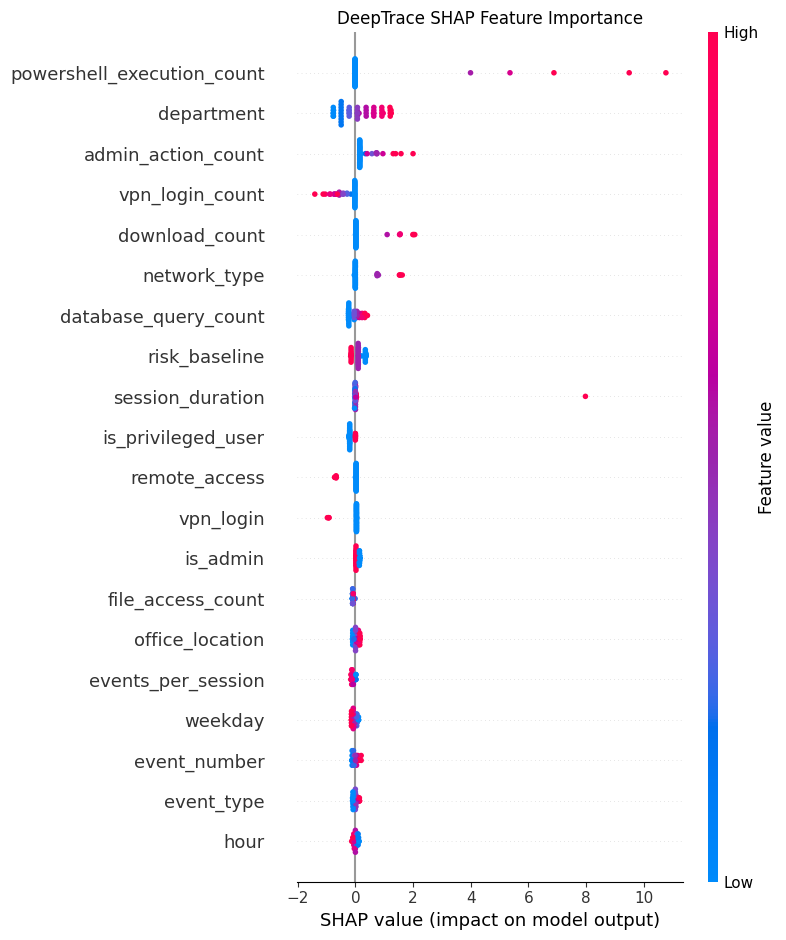

In [11]:
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,
    explain_data,
    feature_names=feature_names,
    show=False
)

plt.title("DeepTrace SHAP Feature Importance")
plt.tight_layout()
plt.show()

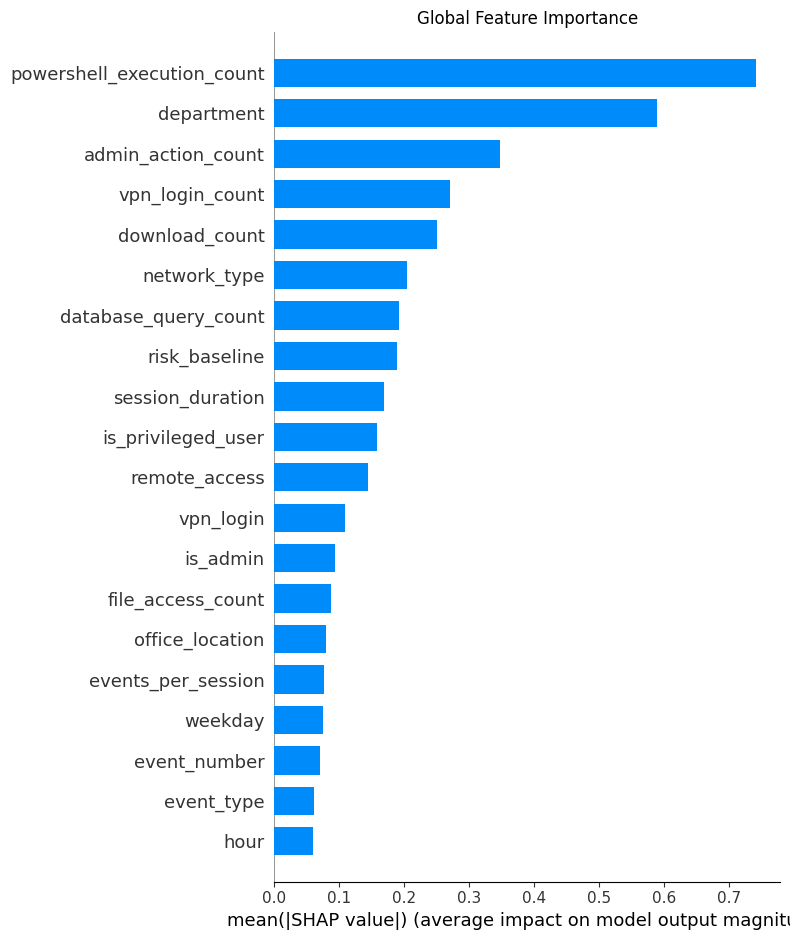

In [12]:
plt.figure(figsize=(12,8))

shap.summary_plot(
    shap_values,
    explain_data,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.title("Global Feature Importance")
plt.tight_layout()
plt.show()

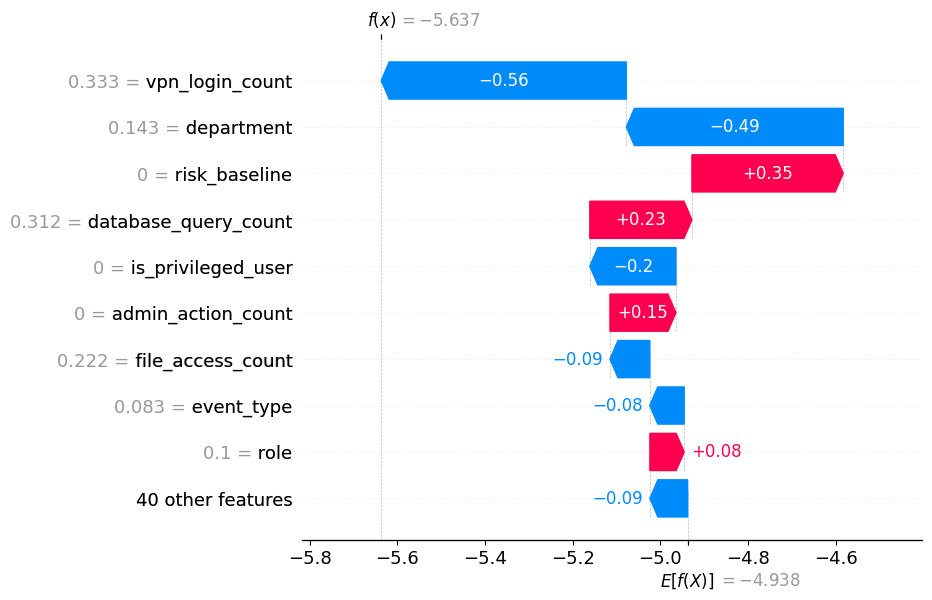

In [13]:
sample_index = 0

explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=explain_data.iloc[sample_index].values,
    feature_names=feature_names
)

shap.plots.waterfall(explanation)

In [14]:
explanations = []

for i in range(len(explain_data)):

    values = shap_values[i]

    top_indices = np.argsort(np.abs(values))[::-1][:5]

    top_features = [
        feature_names[idx]
        for idx in top_indices
    ]

    top_impacts = [
        round(float(values[idx]), 4)
        for idx in top_indices
    ]

    explanation = "; ".join(
        [
            f"{feature} ({impact:+.4f})"
            for feature, impact in zip(top_features, top_impacts)
        ]
    )

    explanations.append(
        {
            "SampleID": i,
            "TopFeatures": ", ".join(top_features),
            "SHAPExplanation": explanation
        }
    )

explanations_df = pd.DataFrame(explanations)

display(explanations_df.head())

,SampleID,TopFeatures,SHAPExplanation
0,0,"vpn_login_count, department, risk_baseline, da...",vpn_login_count (-0.5594); department (-0.4949...
1,1,"database_query_count, admin_action_count, risk...",database_query_count (-0.2185); admin_action_c...
2,2,"database_query_count, is_privileged_user, admi...",database_query_count (-0.2382); is_privileged_...
3,3,"database_query, high_risk_event, database_quer...",database_query (-0.2924); high_risk_event (+0....
4,4,"download_count, department, database_query_cou...",download_count (+2.0611); department (-0.7602)...


In [15]:
explanations_df.to_csv("/content/deeptrace_explanations.csv",index=False)

print("Explainability report saved successfully.")
print(f"Total Explanations : {len(explanations_df)}")
print("/content/deeptrace_explanations.csv")

Explainability report saved successfully.
Total Explanations : 50
/content/deeptrace_explanations.csv
